In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score , r2_score, mean_absolute_error, mean_squared_error
import joblib
import streamlit as st

In [2]:
df=pd.read_csv('patients_pro_max_with_priority.csv')

In [3]:
df.head()

,patient_id,age,gender,heart_rate,respiratory_rate,oxygen_saturation,blood_pressure,pain_level,condition,needs_surgery,surgery_duration,bp_mean,priority
0,P001,67,Female,80,18,96,108/82,2,10,True,73,90.666667,2
1,P002,27,Male,81,22,93,139/75,3,10,True,77,96.333333,3
2,P003,51,Male,104,15,94,137/97,3,9,True,54,110.333333,4
3,P004,69,Male,62,16,97,96/80,2,8,True,47,85.333333,4
4,P005,48,Female,81,23,91,117/84,3,7,True,76,95.000000,6


In [4]:
df['gender']=df['gender'].replace({'Female':0,'Male':1})

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_12748\88103135.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender']=df['gender'].replace({'Female':0,'Male':1})


In [5]:
df.head()

,patient_id,age,gender,heart_rate,respiratory_rate,oxygen_saturation,blood_pressure,pain_level,condition,needs_surgery,surgery_duration,bp_mean,priority
0,P001,67,0,80,18,96,108/82,2,10,True,73,90.666667,2
1,P002,27,1,81,22,93,139/75,3,10,True,77,96.333333,3
2,P003,51,1,104,15,94,137/97,3,9,True,54,110.333333,4
3,P004,69,1,62,16,97,96/80,2,8,True,47,85.333333,4
4,P005,48,0,81,23,91,117/84,3,7,True,76,95.000000,6


In [6]:
df['needs_surgery']=df['needs_surgery'].replace({True:1,False:0})

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_12748\1016333406.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['needs_surgery']=df['needs_surgery'].replace({True:1,False:0})


In [7]:
x=df[['age','gender','heart_rate','respiratory_rate','oxygen_saturation','pain_level','condition','bp_mean','needs_surgery','priority']]
y=df['surgery_duration']

In [8]:
df.isnull().sum()

patient_id           0
age                  0
gender               0
heart_rate           0
respiratory_rate     0
oxygen_saturation    0
blood_pressure       0
pain_level           0
condition            0
needs_surgery        0
surgery_duration     0
bp_mean              0
priority             0
dtype: int64

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print('training feature shape',x_train.shape)
print('testing feature shape',x_test.shape)

training feature shape (12000, 10)
testing feature shape (3000, 10)


In [10]:
lr_model=LinearRegression()
lr_model.fit(x_train, y_train)
y_pred= lr_model.predict(x_test)
r2_model_score=r2_score(y_test,y_pred)
print('the R2 score is : ',r2_model_score)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

the R2 score is :  0.7121135119841208
MAE: 12.14499541865114
MSE: 266.517378244785
RMSE: 16.325359972900596


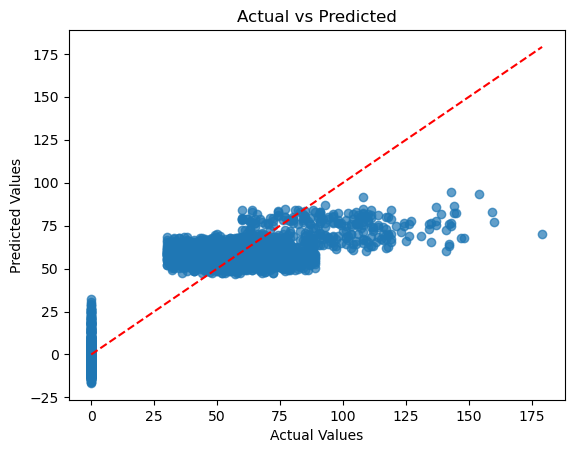

In [11]:


# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# Perfect prediction line
x_line = [min(y_test), max(y_test)]
plt.plot(x_line, x_line, color="red", linestyle="--")

plt.show()


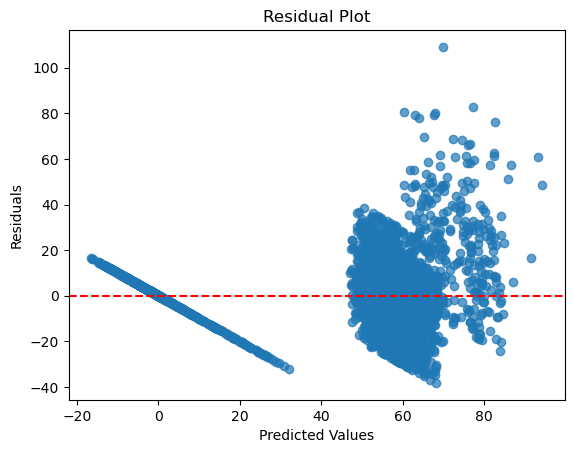

In [12]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [13]:
### Polynominal Regression

In [14]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Fit linear regression on polynomial features
model = LinearRegression()
model.fit(x_train_poly, y_train)

# Predict
y_pred_poly = model.predict(x_test_poly)

# Evaluate
print("R2 score:", r2_score(y_test, y_pred_poly))
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

R2 score: 0.7965225533221805
MAE: 10.086734386022234
MSE: 188.3738135619767
RMSE: 13.724934009385134


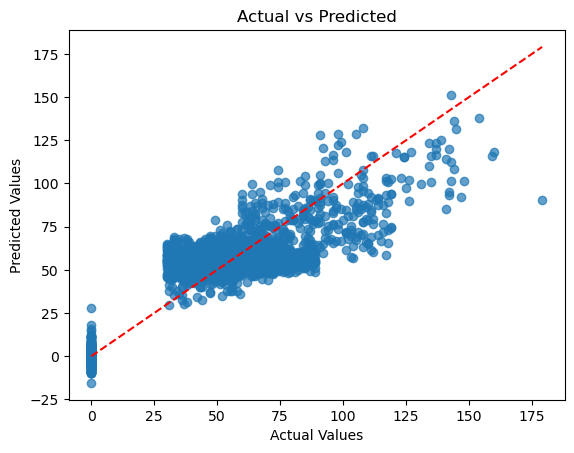

In [15]:


# Scatter plot
plt.scatter(y_test, y_pred_poly, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# Perfect prediction line
x_line = [min(y_test), max(y_test)]
plt.plot(x_line, x_line, color="red", linestyle="--")

plt.show()


### Random Forest Regressor

In [16]:
# Best Parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 180}
# Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
rf_model= RandomForestRegressor(n_estimators=180,max_depth=12,random_state=42,max_features='log2',min_samples_leaf=3,min_samples_split=15)
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)

In [17]:
print("R2 score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 score: 0.9125576242338798
MAE: 6.463392142050015
MSE: 80.95174211648394
RMSE: 8.997318607034206


In [71]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    'n_estimators': stats.randint(100, 1000),
    'max_depth': stats.randint(5, 50),
    'min_samples_split': stats.randint(2, 20),
    'min_samples_leaf': stats.randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2']
}

rand_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    cv=5,
    n_jobs=-1,
    scoring='r2',
    random_state=42,
    verbose=2
)

rand_search.fit(x_train, y_train)
print("Best Parameters:", rand_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\base.py

Best Parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 180}


In [76]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Grid search
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,             # 5-fold cross-validation
    n_jobs=-1,        # use all cores
    scoring='r2',     # optimize for R²
    verbose=2
)

grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Predict and evaluate
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(x_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
267 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Administrateur\anaconda3\Lib\site-packages\sklearn\base

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


NameError: name 'X_test' is not defined

In [19]:
import joblib

# Save the model
joblib.dump(rf_model, "surgery_duration_model.pkl")

['surgery_duration_model.pkl']

In [20]:


import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Load your model
model = joblib.load("surgery_duration_model.pkl")

# Define input shape (batch, features)
initial_type = [('input', FloatTensorType([None, 10]))]

# Convert to ONNX
onnx_model = convert_sklearn(model, initial_types=initial_type)

# Save
with open("surgery_duration_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())


In [30]:
!pip install onnx==1.13.1 onnx-tf==1.10.0

  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [26 lines of output]
  <string>:30: DeprecationWarning: Use shutil.which instead of find_executable
  <string>:31: DeprecationWarning: Use shutil.which instead of find_executable
  fatal: not a git repository (or any of the parent directories): .git
  Traceback (most recent call last):
    File "C:\Users\Administrateur\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
      ~~~~^^
    File "C:\Users\Administrateur\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Administrateur\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
   


     ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
     - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
     - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
     - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
     - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
     - ------------------------------------- 0.5/10.4 MB 367.7 kB/s eta 0:00:27
     -- ------------------------------------ 0.8/10.4 MB 505.7 kB/s eta 0:00:20
     --- ----------------------------------- 1.0/10.4 MB 604.5 kB/s eta 0:00:16
     --- ----------------------------------- 1.0/10.4 MB 604.5 kB/s eta 0:00:16
     ---- ---------------------------------- 1.3/10.4 MB 638.8 kB/s eta 0:00:15
     ------ -------------------------------- 1.8/10.4 MB 831.7 kB/s eta 0:00:11
     ------- ------------------------------- 2.1/10.4 MB 915.7 kB/s eta 0:00:10
     -------- ------------------------------ 2.4/10.4 MB 875.1 kB/s eta 0:00:10

In [28]:
# !pip install tensorflow
import tensorflow as tf

model = tf.saved_model.load("onnx_saved_model")
converter = tf.lite.TFLiteConverter.from_saved_model("onnx_saved_model")
tflite_model = converter.convert()

with open("surgery_duration_model.tflite", "wb") as f:
    f.write(tflite_model)


OSError: SavedModel file does not exist at: onnx_saved_model\{saved_model.pbtxt|saved_model.pb}

In [29]:
import onnx
from onnx_tf.backend import prepare

# Load your ONNX model
onnx_model = onnx.load("surgery_priority_model.onnx")

# Convert to TensorFlow representation
tf_rep = prepare(onnx_model)

# Export as SavedModel
tf_rep.export_graph("tf_saved_model")


ModuleNotFoundError: No module named 'onnx_tf'